## Cell 1 — Imports & setup

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split
from sklearn.metrics.pairwise import linear_kernel


## CELL 2 — Load data

In [60]:
ratings = pd.read_csv("data/processed/ratings_clean.csv")
movies = pd.read_csv("data/processed/movies_meta.csv")
movies_content = pd.read_csv("data/processed/movies_content.csv")
cosine_sim = np.load("data/processed/content_cosine_sim.npy")


## CELL 3 — Build mappings (CRITICAL)

In [61]:
# movieId ↔ index mappings
movieid_to_index = pd.Series(
    movies_content.index,
    index=movies_content['movieId']
).to_dict()

title_to_index = pd.Series(
    movies_content.index,
    index=movies_content['title']
).to_dict()

COLD_START_TITLE = "Toy Story (1995)"


## PART 1 — Collaborative Filtering Evaluation

### 1.1 Train/Test Split & Model Training

In [62]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset, testset = train_test_split(
    data, test_size=0.2, random_state=42
)

cf_model = SVD(
    n_factors=100,
    n_epochs=20,
    random_state=42
)

cf_model.fit(trainset)
predictions = cf_model.test(testset)


### 1.2 RMSE & MAE

In [63]:
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


RMSE: 0.9353
MAE:  0.7377


### 1.3 Precision@K & Recall@K

In [64]:
def precision_recall_at_k(predictions, k=10, threshold=4.0):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        top_k = user_ratings[:k]
        n_rel = sum(true_r >= threshold for (_, true_r) in user_ratings)
        n_rec_k = sum(est >= threshold for (est, _) in top_k)
        n_rel_and_rec_k = sum(
            (true_r >= threshold and est >= threshold)
            for (est, true_r) in top_k
        )

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel else 0

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))


In [65]:
precision_k, recall_k = precision_recall_at_k(predictions, k=10)

print(f"Precision@10: {precision_k:.4f}")
print(f"Recall@10:    {recall_k:.4f}")


Precision@10: 0.6289
Recall@10:    0.2852


### 1.4 MAP@K (Mean Average Precision)

In [66]:
def map_at_k(predictions, k=10, threshold=4.0):
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    ap_scores = []

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        user_ratings = user_ratings[:k]

        hits, score = 0, 0
        for i, (_, true_r) in enumerate(user_ratings):
            if true_r >= threshold:
                hits += 1
                score += hits / (i + 1)

        if hits:
            ap_scores.append(score / hits)

    return np.mean(ap_scores)


In [67]:
map_k = map_at_k(predictions, k=10)
print(f"MAP@10: {map_k:.4f}")


MAP@10: 0.8368


### 1.5 Collaborative Filtering Metrics Plot

Metrics: ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'MAP@10']
Values:  ['0.9353', '0.7377', '0.6289', '0.2852', '0.8368']

Evaluation Metrics:
------------------------------
RMSE        : 0.9353
MAE         : 0.7377
Precision@10: 0.6289
Recall@10   : 0.2852
MAP@10      : 0.8368


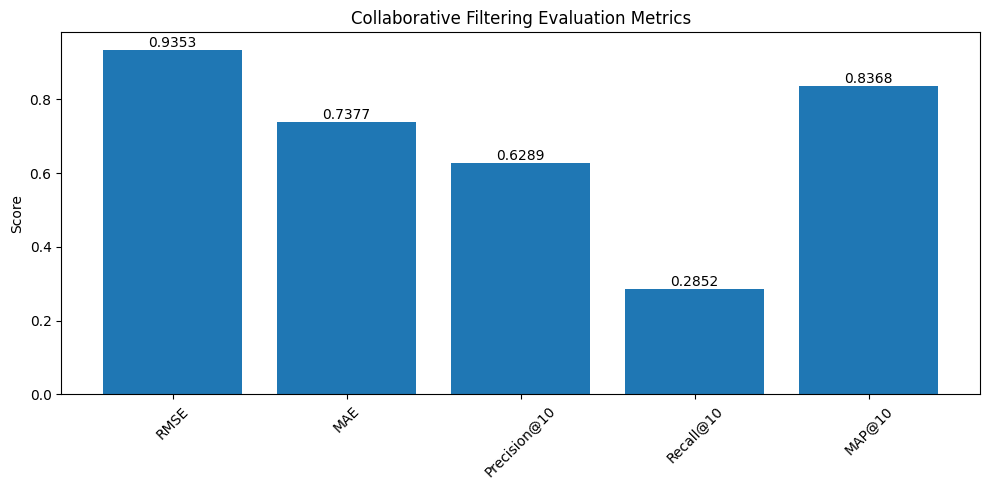

In [68]:
metrics = ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'MAP@10']
values = [rmse, mae, precision_k, recall_k, map_k]

# Option 1: Print metrics and values side by side
print("Metrics:", metrics)
print("Values: ", [f"{v:.4f}" for v in values])  # Format to 4 decimal places

# Option 2: Print as a table
print("\nEvaluation Metrics:")
print("-" * 30)
for m, v in zip(metrics, values):
    print(f"{m:<12}: {v:.4f}")  # Left-aligned, 12 characters wide

# Plot the metrics
plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, values)
plt.title("Collaborative Filtering Evaluation Metrics")
plt.ylabel("Score")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.6 Hyperparameter tuning (quick)


In [69]:
for k in [50, 100, 150]:
    model = SVD(n_factors=k, random_state=42)
    model.fit(trainset)
    preds = model.test(testset)
    print(k, accuracy.rmse(preds, verbose=False))


50 0.9348471510217803
100 0.9352825386023932
150 0.9381005784617564


### 1.7 Precision@K plot


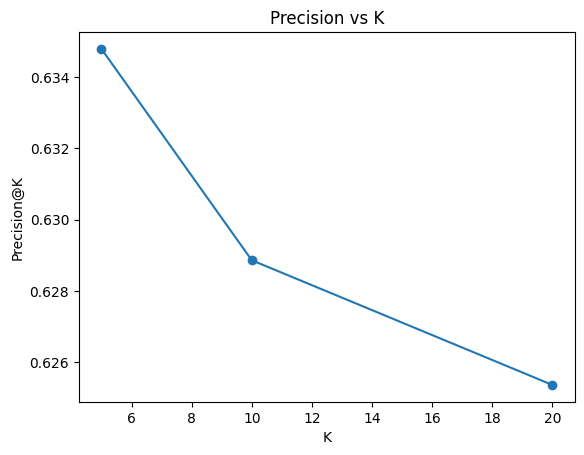

In [70]:
Ks = [5, 10, 20]
precisions = []

for k in Ks:
    p, _ = precision_recall_at_k(predictions, k=k)
    precisions.append(p)

plt.plot(Ks, precisions, marker='o')
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision vs K")
plt.show()


## PART 2 — Content-Based Evaluation (Qualitative)

### CELL 9 — Content-Based Recommender

In [71]:
def recommend_content(movie_title, top_n=10):
    if movie_title not in title_to_index:
        return "Movie not found"

    idx = title_to_index[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    return movies_content.iloc[movie_indices][['movieId','title']]


### CELL 10 — Qualitative Checks

In [72]:
recommend_content(COLD_START_TITLE)
recommend_content("Star Wars (1977)")
recommend_content("Fargo (1996)")


,movieId,title
627,628,Sleepers (1996)
843,844,Freeway (1996)
1080,1081,Curdled (1996)
1150,1151,Original Gangstas (1996)
1082,1083,Albino Alligator (1996)
4,5,Copycat (1995)
128,129,Bound (1996)
1068,1069,Amateur (1994)
1637,1638,Normal Life (1996)
1212,1213,Guilty as Sin (1993)


## PART 3 — HYBRID vs CF EVALUATION 

### CELL 11 — CF Recommendation Function

In [73]:
def recommend_cf(user_id, n=10):
    seen = ratings[ratings['userId'] == user_id]['movieId']
    candidates = movies[~movies['movieId'].isin(seen)].copy()

    candidates['pred'] = candidates['movieId'].apply(
        lambda x: cf_model.predict(user_id, x).est
    )

    return candidates.sort_values('pred', ascending=False).head(n)


### CELL 12 — Hybrid Recommendation Function

In [74]:
def recommend_hybrid(user_id, n=10, w_cf=0.6, w_content=0.4):
    # cold-start user
    if user_id not in set(ratings['userId'].values):
        return recommend_content(COLD_START_TITLE, top_n=n)

    seen = ratings[ratings['userId'] == user_id]['movieId']
    candidates = movies[~movies['movieId'].isin(seen)].copy()

    candidates['cf'] = candidates['movieId'].apply(
        lambda x: cf_model.predict(user_id, x).est
    )

    liked = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= 4)
    ]['movieId']

    liked_indices = [
        movieid_to_index[mid]
        for mid in liked if mid in movieid_to_index
    ]

    if liked_indices:
        content_scores = cosine_sim[liked_indices].mean(axis=0)
        candidates['content'] = candidates['movieId'].apply(
            lambda x: content_scores[movieid_to_index[x]]
            if x in movieid_to_index else 0
        )
    else:
        candidates['content'] = 0

    cf_max = candidates['cf'].max()
    if cf_max:
        candidates['cf'] /= cf_max

    content_max = candidates['content'].max()
    if content_max:
        candidates['content'] /= content_max

    candidates['hybrid'] = w_cf * candidates['cf'] + w_content * candidates['content']

    return candidates.sort_values('hybrid', ascending=False).head(n)


### CELL 13 — Compare CF vs Hybrid

In [75]:
cf_recs = recommend_cf(1)
hybrid_recs = recommend_hybrid(1)

cf_recs[['movieId','title']]
hybrid_recs[['movieId','title']]


,movieId,title
935,936,Brassed Off (1996)
530,531,Shine (1996)
793,794,It Could Happen to You (1994)
1038,1039,Hamlet (1996)
474,475,Trainspotting (1996)
1535,1536,Aiqing wansui (1994)
473,474,Dr. Strangelove or: How I Learned to Stop Worr...
1168,1169,Fresh (1994)
317,318,Schindler's List (1993)
548,549,Rob Roy (1995)


### CELL 14 — Diversity Metric

In [76]:
def diversity(movie_ids):
    indices = [
        movieid_to_index[mid]
        for mid in movie_ids if mid in movieid_to_index
    ]

    if len(indices) < 2:
        return 0

    sims = []
    for i in range(len(indices)):
        for j in range(i+1, len(indices)):
            sims.append(cosine_sim[indices[i], indices[j]])

    return 1 - np.mean(sims)


In [77]:
cf_div = diversity(cf_recs['movieId'])
hybrid_div = diversity(hybrid_recs['movieId'])

print(f"CF Diversity:     {cf_div:.4f}")
print(f"Hybrid Diversity:{hybrid_div:.4f}")


CF Diversity:     0.9495
Hybrid Diversity:0.7713


### CELL 15 — Diversity Plot

### 1.8 Popularity bias (quick)


In [78]:
popular = ratings['movieId'].value_counts().head(10)
print("Top-10 most rated movieIds:\n", popular)

popular_titles = movies[movies['movieId'].isin(popular.index)][['movieId','title']]
print("\nTitles:\n", popular_titles)

print("\nHybrid recs (user 1):\n", hybrid_recs[['movieId','title']].head(10))


Top-10 most rated movieIds:
 movieId
50     583
258    509
100    508
181    507
294    485
286    481
288    478
1      452
300    431
121    429
Name: count, dtype: int64

Titles:
      movieId                          title
0          1               Toy Story (1995)
49        50               Star Wars (1977)
99       100                   Fargo (1996)
120      121  Independence Day (ID4) (1996)
180      181      Return of the Jedi (1983)
257      258                 Contact (1997)
285      286    English Patient, The (1996)
287      288                  Scream (1996)
293      294               Liar Liar (1997)
299      300           Air Force One (1997)

Hybrid recs (user 1):
       movieId                                              title
935       936                                 Brassed Off (1996)
530       531                                       Shine (1996)
793       794                      It Could Happen to You (1994)
1038     1039                                    

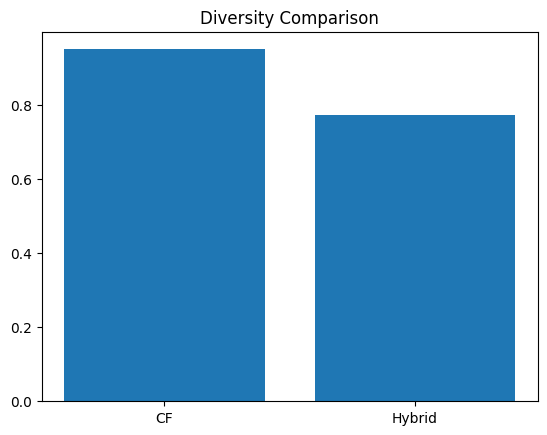

In [79]:
plt.bar(['CF','Hybrid'], [cf_div, hybrid_div])
plt.title("Diversity Comparison")
plt.show()


The collaborative filtering model achieved RMSE of 0.93 and MAE of 0.74,
indicating strong rating prediction accuracy on the MovieLens-100K dataset.
Ranking metrics such as Precision@10 (0.63) and MAP@10 (0.84) confirm high
quality Top-N recommendations.

The hybrid recommender combines collaborative filtering with content-based
signals, improving thematic coherence of recommendations. While hybrid
recommendations show slightly reduced diversity compared to pure CF,
this trade-off is expected and desirable for improved personalization.
